In [ ]:
from watts.parameters import Parameters
from watts.results import ExecInfo, Results
from watts.plugin_cyclus import ResultsCyclus

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [ ]:

inputs = []
outputs = ['./nuc46_nz50_ot2.sqlite']

obj = ResultsCyclus(Parameters(), ExecInfo(1, 'cyclus', 'name', 1),
                    inputs, outputs)
cyclus = obj.obj
natu_assay = 0.00711
tails_assay = 0.0025
years = np.array(range(int(cyclus.years[0]), int(cyclus.years[-1]) + 1))
min_year = 2020
years_idx = np.where(years >= min_year)[0]


# Group reactors per reactor type and fuel type

In [95]:
# Get all reactor prototype names used in the simulation
all_reactors = list(obj.reactors.values())

# Define named reactor categories of interest
named_reactors = ['AP1000', 'VOYGR', '12VOYGR', 'Natrium', 'XE100', '4XE100', 'VOGTLE-3', 'VOGTLE-4']

# Classify all remaining reactors as "Legacy"
legacy_protos = [r for r in all_reactors if r not in named_reactors]

# Group named reactors by name similarity (e.g., "VOYGR" and "12VOYGR")
grouped_reactors = {}
remaining = set(named_reactors)

# VOGTLE-3 and VOGTLE-4 are special, remove from remaining
remaining = remaining - {reactor for reactor in ['VOGTLE-3', 'VOGTLE-4'] if reactor in all_reactors}

while remaining:
    name = remaining.pop()
    # Collect all names containing or contained by `name`
    group = sorted({r for r in remaining | {name} if name in r or r in name})
    key = min(group, key=len)  # Use the shortest name as the group label
    grouped_reactors[key] = group
    remaining -= set(group) - {name}  # Remove grouped names (except current one, already popped)

# Add VOGTLE to AP1000 group
if 'VOGTLE-3' in all_reactors:
    grouped_reactors['AP1000'] += ['VOGTLE-3']
if 'VOGTLE-4' in all_reactors:
    grouped_reactors['AP1000'] += ['VOGTLE-4']

# Add legacy group explicitly
grouped_reactors['Legacy'] = legacy_protos

# Sort by number of reactors in each group, descending
grouped_reactors = dict(sorted(grouped_reactors.items(), key=lambda item: len(item[1]), reverse=True))

# Super groups
supergrouped_reactors = {
    'UOX': grouped_reactors['AP1000'] + grouped_reactors['VOYGR'] + grouped_reactors['Legacy'],
    'Metal': grouped_reactors['Natrium'],
    'TRISO': grouped_reactors['XE100']
}    

# Function to load and plot all data

In [96]:
def apply_to_all_reactors(grouped_reactors, func, valid_idx=None, scale=1, **kwargs):
    """
    Apply a function to all reactors in the list and return a dictionary with reactor names as keys and results as values.
    """
    # Header: intro + parameters
    func_name = func.__name__
    print(f"Applying function: {func_name} to all reactors: {list(grouped_reactors.keys())}")
    print(f"-"*50)
    if kwargs:
        print(f"Function parameters:")
        for key, value in kwargs.items():
            print(f"\t- {key}: {value}")
        print(f"-"*50)
    # Iterate through each reactor group
    new_data = {}
    for reactor_name, protos in grouped_reactors.items():
        val = func(protos, **kwargs)
        if not np.all(val==0):
            print(f"Processing {reactor_name} with prototypes: {protos}")
            # Scale
            if isinstance(val, dict):
                val = {k: v * scale for k, v in val.items()}       
                if valid_idx is not None:
                    val = {k: v[valid_idx] for k, v in val.items()}
            else:
                val = val * scale
                if valid_idx is not None:
                    val = val[valid_idx]
            new_data[reactor_name] = val
            try:
                print(f'\tMin: {np.min(val):.4g}, Mean: {np.mean(val):.4g}, Max: {np.max(val):.4g}')
            except:
                pass
        
    return new_data

def plot_all_reactors(DATA, key, years=None, plot_tot=True, ax=None, cumulate=False, **kwargs):
    """
    Plot all reactors in the data dictionary.
    """
    DEFAULT_KWARGS = {
        'xlabel': 'Year',
        'legend': True,
        'ylim': (0, None),
        'xlim': (years[0], years[-1]) if years is not None else None,
        'grid': True,
        'alpha': 0.4,
    }
    kwargs = {**DEFAULT_KWARGS, **kwargs}

    data = DATA[key]

    if ax is None:
        fig, ax = plt.subplots()
    if years is None:
        years = range(len(next(iter(data.values()))))

    if not cumulate:
        for reactor_name, values in data.items():
            ax.plot(years, values, label=reactor_name)
        if plot_tot:
            total = np.sum(list(data.values()), axis=0)
            ax.plot(years, total, label='Total', color='black', linestyle='--')
    else:
        labels = list(data.keys())
        values = np.array(list(data.values()))
        ax.stackplot(years, values, labels=labels, alpha=kwargs.pop('alpha', 0.4))

    # Apply visual settings
    apply_plot_kwargs(ax, kwargs)
    
    return ax

def plot_one_reactor(DATA, reactor, years=None, ax=None, **kwargs):
    """
    Plot all available data for a single reactor.
    """
    DEFAULT_KWARGS = {
        'xlabel': 'Year',
        'legend': True,
        'ylim': (0, None),
        'xlim': (years[0], years[-1]) if years is not None else None,
        'grid': True,
        'alpha': 0.4,
    }
    kwargs = {**DEFAULT_KWARGS, **kwargs}

    keys = [k for k in DATA.keys() if reactor in DATA[k]]
    if not keys:
        print(f"No data available for reactor {reactor}.")
        return
    data = {k: DATA[k][reactor] for k in keys}

    if ax is None:
        fig, ax = plt.subplots()
    if years is None:
        years = range(len(next(iter(data.values()))))

    for reactor_name, values in data.items():
        ax.plot(years, values, label=reactor_name)

    # Apply visual settings
    apply_plot_kwargs(ax, kwargs)
    
    return ax

def apply_plot_kwargs(ax, kwargs):
    """
    Apply matplotlib kwargs to ax or plt with fallback to common patterns.
    Raises ValueError for unknown or invalid keys.
    """
    import matplotlib.pyplot as plt

    def try_apply(obj, method_name, value):
        method = getattr(obj, method_name, None)
        if callable(method):
            try:
                method(value)
            except Exception:
                if value is True:
                    method()
                else:
                    raise ValueError(f"Invalid value for {method_name}: {value}")
            return True
        return False

    for key, value in kwargs.items():
        # Try ax.set_<key>, then ax.<key>, then plt.set_<key>, then plt.<key>
        if not (
            try_apply(ax, f'set_{key}', value) or
            try_apply(ax, key, value) or
            try_apply(plt, f'set_{key}', value) or
            try_apply(plt, key, value)
        ):
            raise ValueError(f"Invalid attribute: {key}")



# Load all data and plot stacked areas

Applying function: stock_fuel_demand to all reactors: ['Legacy', 'AP1000', 'XE100', 'VOYGR', 'Natrium']
--------------------------------------------------
Function parameters:
	- natu_assay: 0.00711
	- tails_assay: 0.0025
--------------------------------------------------
Applying function: stock_fuel_demand to all reactors: ['Legacy', 'AP1000', 'XE100', 'VOYGR', 'Natrium']
--------------------------------------------------
Processing Legacy with prototypes: ['NINE MILE POINT-1', 'DRESDEN-2', 'GINNA', 'POINT BEACH-1', 'ROBINSON-2', 'MONTICELLO', 'DRESDEN-3', 'PALISADES', 'POINT BEACH-2', 'TURKEY POINT-3', 'SURRY-1', 'QUAD CITIES-1', 'QUAD CITIES-2', 'SURRY-2', 'OCONEE-1', 'TURKEY POINT-4', 'PRAIRIE ISLAND-1', 'PEACH BOTTOM-2', 'COOPER', 'BROWNS FERRY-1', 'OCONEE-2', 'OCONEE-3', 'PEACH BOTTOM-3', 'ANO-1', 'PRAIRIE ISLAND-2', 'BROWNS FERRY-2', 'CALVERT CLIFFS-1', 'FITZPATRICK', 'COOK-1', 'BRUNSWICK-2', 'HATCH-1', 'MILLSTONE-2', 'INDIAN POINT-3', 'BEAVER VALLEY-1', 'ST. LUCIE-1', 'BROWNS 

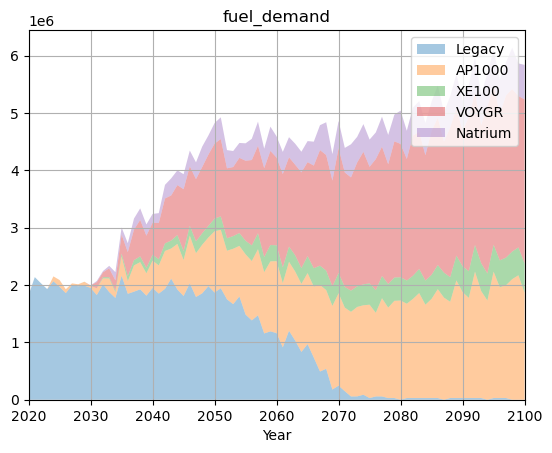

**************************************************
Applying function: stock_fuel_discharged to all reactors: ['Legacy', 'AP1000', 'XE100', 'VOYGR', 'Natrium']
--------------------------------------------------
Function parameters:
	- natu_assay: 0.00711
	- tails_assay: 0.0025
--------------------------------------------------
Applying function: stock_fuel_discharged to all reactors: ['Legacy', 'AP1000', 'XE100', 'VOYGR', 'Natrium']
--------------------------------------------------
Processing Legacy with prototypes: ['NINE MILE POINT-1', 'DRESDEN-2', 'GINNA', 'POINT BEACH-1', 'ROBINSON-2', 'MONTICELLO', 'DRESDEN-3', 'PALISADES', 'POINT BEACH-2', 'TURKEY POINT-3', 'SURRY-1', 'QUAD CITIES-1', 'QUAD CITIES-2', 'SURRY-2', 'OCONEE-1', 'TURKEY POINT-4', 'PRAIRIE ISLAND-1', 'PEACH BOTTOM-2', 'COOPER', 'BROWNS FERRY-1', 'OCONEE-2', 'OCONEE-3', 'PEACH BOTTOM-3', 'ANO-1', 'PRAIRIE ISLAND-2', 'BROWNS FERRY-2', 'CALVERT CLIFFS-1', 'FITZPATRICK', 'COOK-1', 'BRUNSWICK-2', 'HATCH-1', 'MILLSTONE-2', '

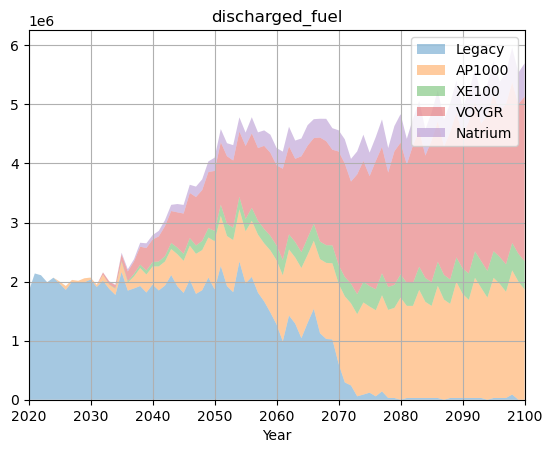

**************************************************
Applying function: stock_fuel_natu to all reactors: ['Legacy', 'AP1000', 'XE100', 'VOYGR', 'Natrium']
--------------------------------------------------
Function parameters:
	- natu_assay: 0.00711
	- tails_assay: 0.0025
--------------------------------------------------
Processing Legacy with prototypes: ['NINE MILE POINT-1', 'DRESDEN-2', 'GINNA', 'POINT BEACH-1', 'ROBINSON-2', 'MONTICELLO', 'DRESDEN-3', 'PALISADES', 'POINT BEACH-2', 'TURKEY POINT-3', 'SURRY-1', 'QUAD CITIES-1', 'QUAD CITIES-2', 'SURRY-2', 'OCONEE-1', 'TURKEY POINT-4', 'PRAIRIE ISLAND-1', 'PEACH BOTTOM-2', 'COOPER', 'BROWNS FERRY-1', 'OCONEE-2', 'OCONEE-3', 'PEACH BOTTOM-3', 'ANO-1', 'PRAIRIE ISLAND-2', 'BROWNS FERRY-2', 'CALVERT CLIFFS-1', 'FITZPATRICK', 'COOK-1', 'BRUNSWICK-2', 'HATCH-1', 'MILLSTONE-2', 'INDIAN POINT-3', 'BEAVER VALLEY-1', 'ST. LUCIE-1', 'BROWNS FERRY-3', 'BRUNSWICK-1', 'CALVERT CLIFFS-2', 'SALEM-1', 'FARLEY-1', 'NORTH ANNA-1', 'COOK-2', 'DAVIS BESSE

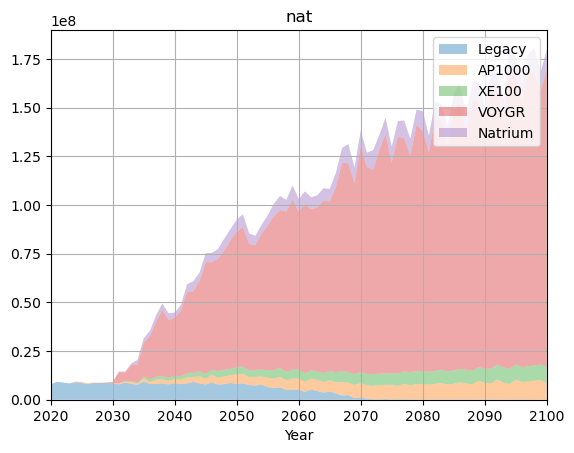

**************************************************
Applying function: stock_fuel_tails to all reactors: ['Legacy', 'AP1000', 'XE100', 'VOYGR', 'Natrium']
--------------------------------------------------
Function parameters:
	- natu_assay: 0.00711
	- tails_assay: 0.0025
--------------------------------------------------
Processing Legacy with prototypes: ['NINE MILE POINT-1', 'DRESDEN-2', 'GINNA', 'POINT BEACH-1', 'ROBINSON-2', 'MONTICELLO', 'DRESDEN-3', 'PALISADES', 'POINT BEACH-2', 'TURKEY POINT-3', 'SURRY-1', 'QUAD CITIES-1', 'QUAD CITIES-2', 'SURRY-2', 'OCONEE-1', 'TURKEY POINT-4', 'PRAIRIE ISLAND-1', 'PEACH BOTTOM-2', 'COOPER', 'BROWNS FERRY-1', 'OCONEE-2', 'OCONEE-3', 'PEACH BOTTOM-3', 'ANO-1', 'PRAIRIE ISLAND-2', 'BROWNS FERRY-2', 'CALVERT CLIFFS-1', 'FITZPATRICK', 'COOK-1', 'BRUNSWICK-2', 'HATCH-1', 'MILLSTONE-2', 'INDIAN POINT-3', 'BEAVER VALLEY-1', 'ST. LUCIE-1', 'BROWNS FERRY-3', 'BRUNSWICK-1', 'CALVERT CLIFFS-2', 'SALEM-1', 'FARLEY-1', 'NORTH ANNA-1', 'COOK-2', 'DAVIS BESS

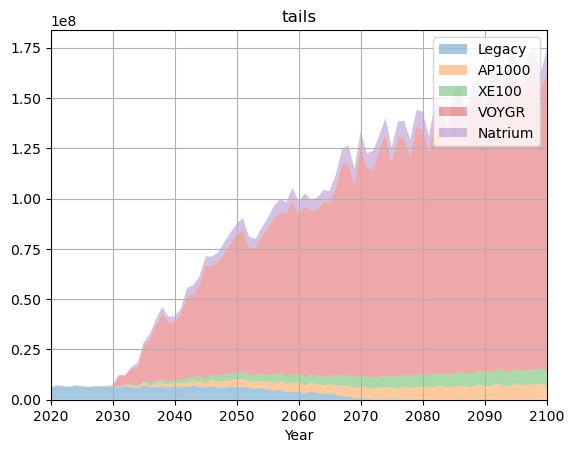

**************************************************
Applying function: stock_fuel_swu to all reactors: ['Legacy', 'AP1000', 'XE100', 'VOYGR', 'Natrium']
--------------------------------------------------
Function parameters:
	- natu_assay: 0.00711
	- tails_assay: 0.0025
--------------------------------------------------
Processing Legacy with prototypes: ['NINE MILE POINT-1', 'DRESDEN-2', 'GINNA', 'POINT BEACH-1', 'ROBINSON-2', 'MONTICELLO', 'DRESDEN-3', 'PALISADES', 'POINT BEACH-2', 'TURKEY POINT-3', 'SURRY-1', 'QUAD CITIES-1', 'QUAD CITIES-2', 'SURRY-2', 'OCONEE-1', 'TURKEY POINT-4', 'PRAIRIE ISLAND-1', 'PEACH BOTTOM-2', 'COOPER', 'BROWNS FERRY-1', 'OCONEE-2', 'OCONEE-3', 'PEACH BOTTOM-3', 'ANO-1', 'PRAIRIE ISLAND-2', 'BROWNS FERRY-2', 'CALVERT CLIFFS-1', 'FITZPATRICK', 'COOK-1', 'BRUNSWICK-2', 'HATCH-1', 'MILLSTONE-2', 'INDIAN POINT-3', 'BEAVER VALLEY-1', 'ST. LUCIE-1', 'BROWNS FERRY-3', 'BRUNSWICK-1', 'CALVERT CLIFFS-2', 'SALEM-1', 'FARLEY-1', 'NORTH ANNA-1', 'COOK-2', 'DAVIS BESSE-

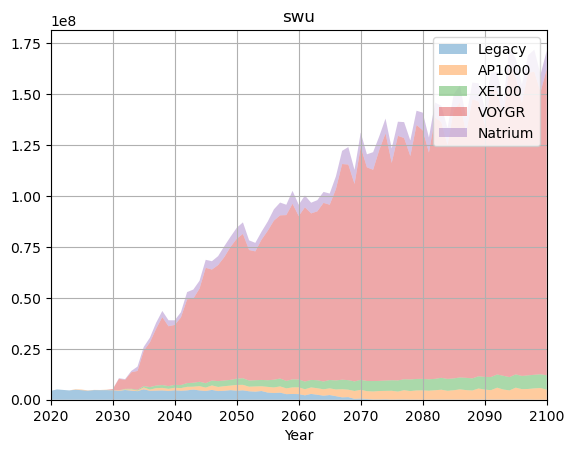

**************************************************


In [97]:
mapping_key_func = {
    'fuel_demand': cyclus.stock_fuel_demand,
    'discharged_fuel': cyclus.stock_fuel_discharged,
    'nat': cyclus.stock_fuel_natu,
    'tails': cyclus.stock_fuel_tails,
    'swu': cyclus.stock_fuel_swu,
}

reactors_of_interest = grouped_reactors

DATA = {}
for key, func in mapping_key_func.items():
    try:
        DATA[key] = apply_to_all_reactors(reactors_of_interest, func, valid_idx=years_idx, scale=1, natu_assay=natu_assay, tails_assay=tails_assay)
    except:
        DATA[key] = apply_to_all_reactors(reactors_of_interest, func, valid_idx=years_idx, scale=1)
    plot_all_reactors(DATA, key, years=years[years_idx], plot_tot=True, cumulate=True, title=key)
    plt.show()
    print('*'*50)



# Plot per reactor type

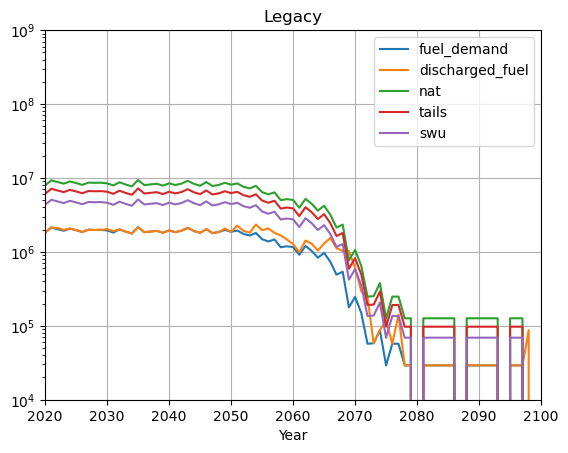

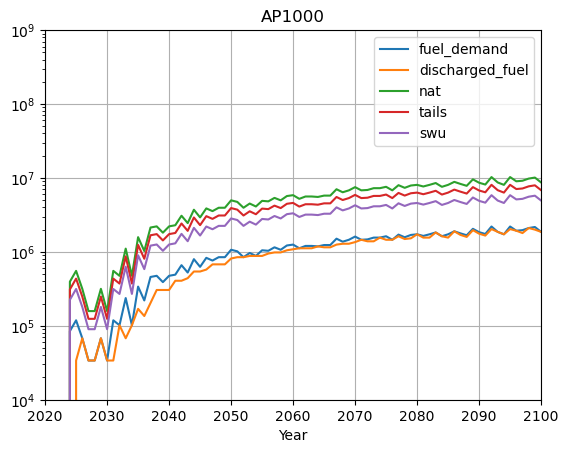

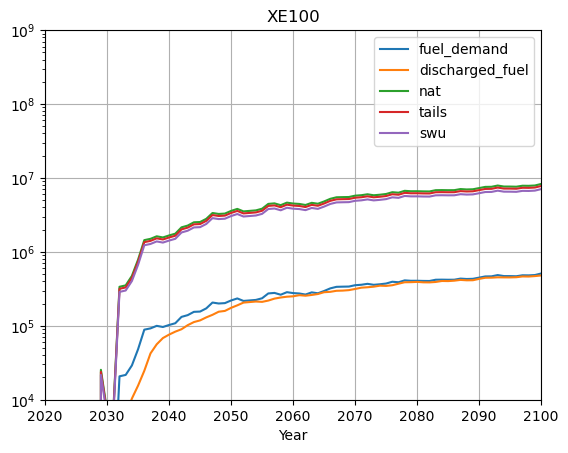

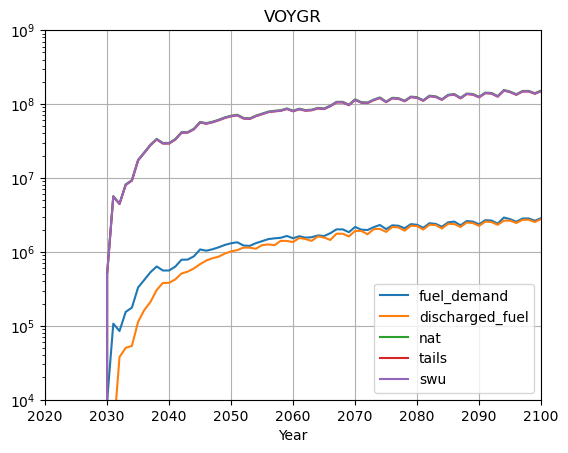

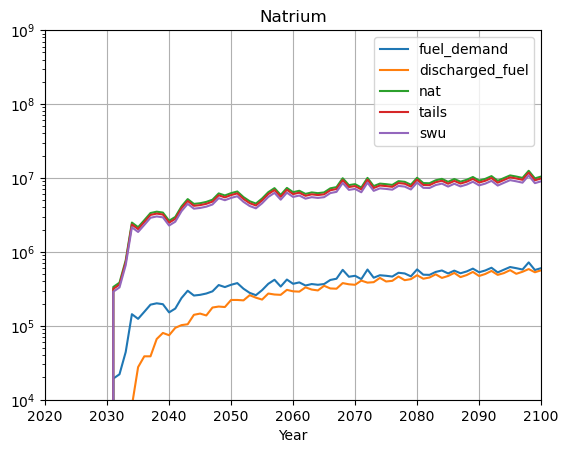

In [98]:
for reactor in reactors_of_interest:
    plot_one_reactor(DATA, reactor, years=years[years_idx], title=reactor, yscale='log', ylim=[1e4, 1e9])

# Group reactors per reactor type and fuel type